In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = [10,8]
plt.rcParams['figure.max_open_warning'] = 50
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import imblearn

C:\Users\User\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
data = pd.read_csv("TUANDROMD.csv")

In [4]:
Class = data.Label

In [5]:
data = data.drop("Label", axis=1).copy()
data["Class"] = Class

In [6]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,malware
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,malware
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,malware
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,malware
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,malware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4459,0,1,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,1,0,goodware
4460,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,0,0,goodware
4461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,goodware
4462,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,goodware


In [7]:
data.shape

(4464, 242)

In [8]:
ls = ["malware","goodware"]

In [9]:
for i in ls:
    if(i == "goodware"):
        data.Class[data.Class == i] = 0
    else:
        data.Class[data.Class == i] = 1

<ipython-input-9-ac66a2c12063>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Class[data.Class == i] = 1
<ipython-input-9-ac66a2c12063>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Class[data.Class == i] = 0


In [10]:
data.Class

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: Class, Length: 4464, dtype: object

In [11]:
Counter(data.Class)

Counter({1: 3565, 0: 899})

In [12]:
classes = []
counts=[]
for i in range(0,2):
    classes.append(i)
    x = data['Class'].value_counts()[i]
    counts.append(x)
print(counts)
dataframe = pd.DataFrame(classes,counts)
print(classes)

[899, 3565]
[0, 1]


In [13]:
dataframe = pd.DataFrame({'Class':["benign", "malware"],'Counts': [899, 3565]})

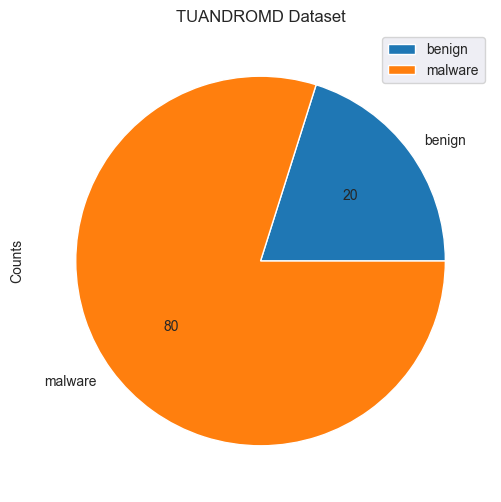

In [15]:
dataframe.groupby(['Class']).sum().plot(kind='pie', y='Counts', figsize=(6,6), autopct='%1.0f', title = "TUANDROMD Dataset")
plt.savefig("TUANDROMD-pie-pic")
plt.show()

In [88]:
data.Class = data['Class'].astype(np.int64)

In [89]:
data.Class

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: Class, Length: 4464, dtype: int64

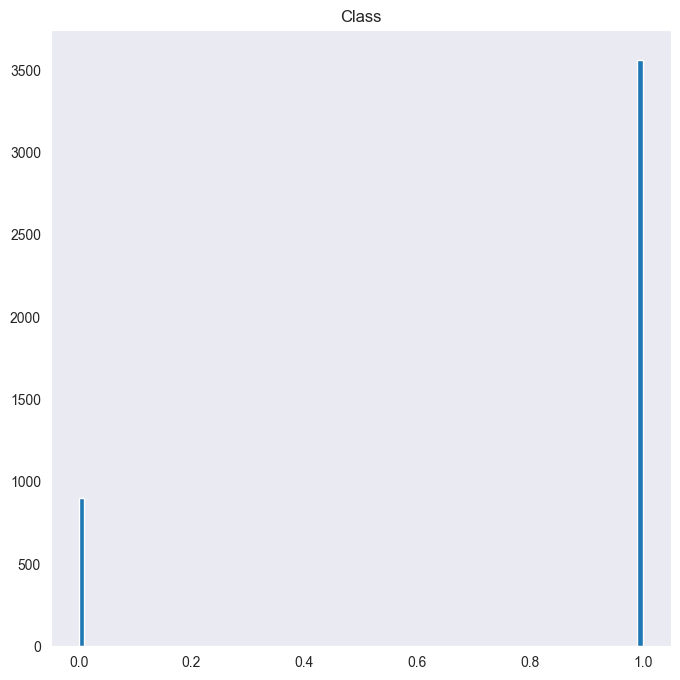

In [90]:
data.hist(column='Class',figsize=(8,8), bins=100, grid = False, zorder=2, rwidth=0.9)
plt.show()

# 2-OverSampling using SMOTE

In [91]:
import imblearn
print(imblearn.__version__)

0.10.1


In [92]:
y = data.Class.copy()
x = data.drop("Class", axis=1).copy()

In [93]:
x

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4459,0,1,0,0,0,0,0,1,1,1,...,1,0,0,0,0,0,0,0,1,0
4460,0,0,0,0,0,0,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0
4461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4462,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [94]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: Class, Length: 4464, dtype: int64

In [95]:
counter = Counter(y)
for k,v in counter.items():
     per = v / len(y) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=3565 (79.861%)
Class=0, n=899 (20.139%)


In [96]:
Counter(data.Class)

Counter({1: 3565, 0: 899})

In [97]:
counter

Counter({1: 3565, 0: 899})

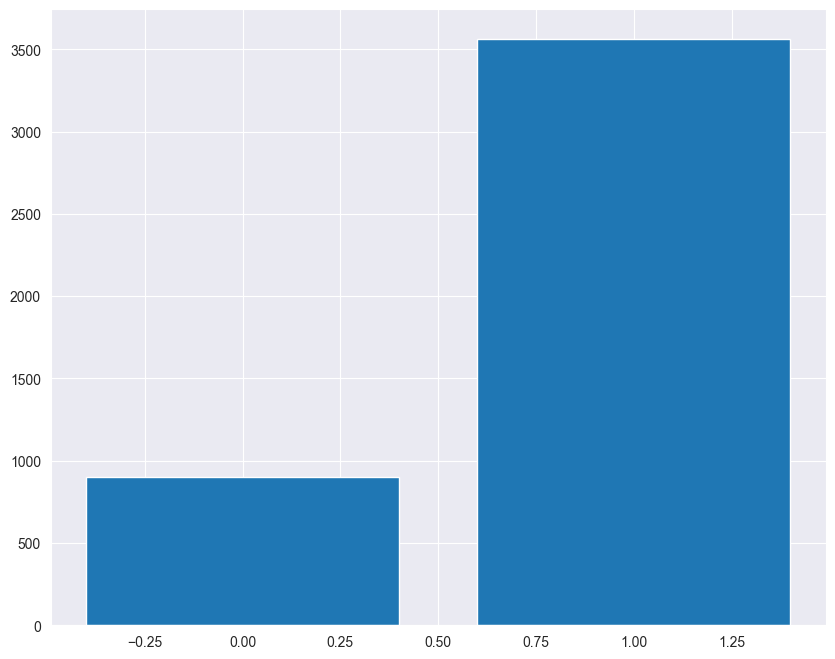

In [98]:
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

In [99]:
from imblearn.over_sampling import SMOTE

In [100]:
overSample = SMOTE()
x,y = overSample.fit_resample(x,y)
OverSampleCounter = Counter(y)

In [101]:
for k,v in OverSampleCounter.items():
     per = v / len(y) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=3565 (50.000%)
Class=0, n=3565 (50.000%)


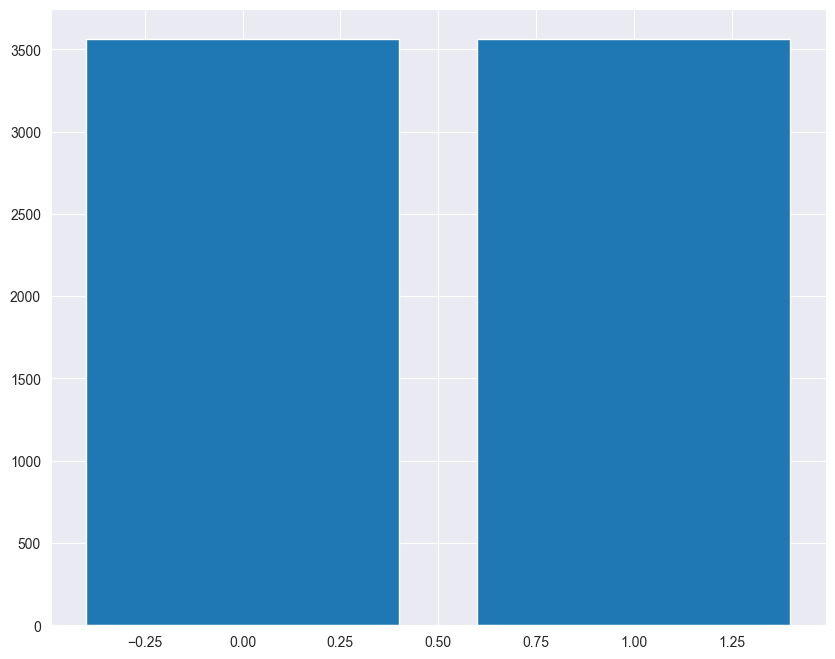

In [102]:
pyplot.bar(counter.keys(), OverSampleCounter.values())
pyplot.show()

In [103]:
x

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [104]:
y

0       1
1       1
2       1
3       1
4       1
       ..
7125    0
7126    0
7127    0
7128    0
7129    0
Name: Class, Length: 7130, dtype: int64

In [105]:
y.unique()

array([1, 0], dtype=int64)

# 3-Outlier Handling

In [106]:
features = data.drop("Class", axis=1).copy()
classes = data.Class.copy()

In [107]:
features

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4459,0,1,0,0,0,0,0,1,1,1,...,1,0,0,0,0,0,0,0,1,0
4460,0,0,0,0,0,0,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0
4461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4462,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [108]:
classes

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: Class, Length: 4464, dtype: int64

In [109]:
Counter(classes)

Counter({1: 3565, 0: 899})

In [110]:
overSample = SMOTE()
features,classes = overSample.fit_resample(features,classes)
OverSampleCounter = Counter(classes)

In [111]:
counter = Counter(classes)
for k,v in OverSampleCounter.items():
     per = v / len(classes) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=3565 (50.000%)
Class=0, n=3565 (50.000%)


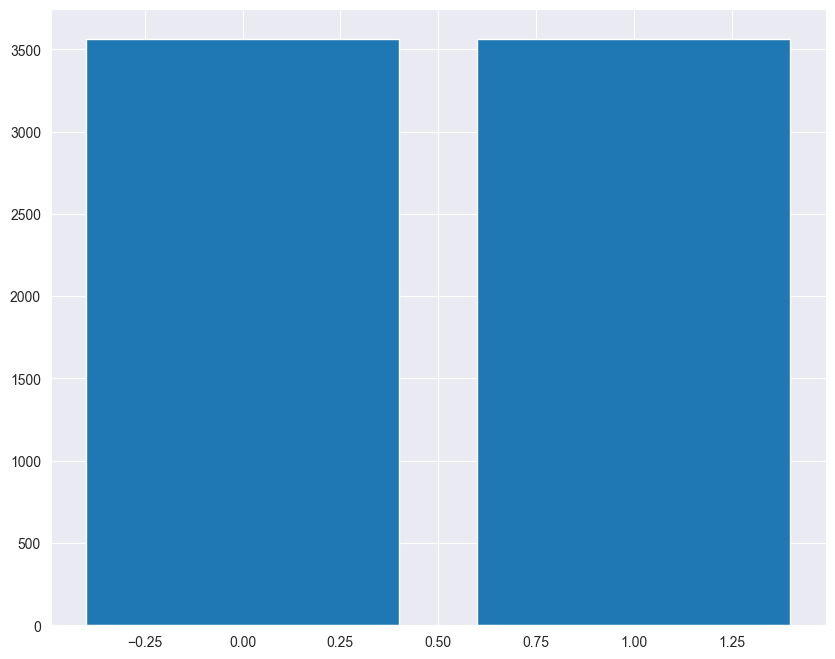

In [112]:
pyplot.bar(counter.keys(), OverSampleCounter.values())
pyplot.show()

In [113]:
features

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,1,1,1,1,0,0
7126,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,1,...,1,0,1,1,1,1,1,1,0,0
7128,0,0,0,0,0,0,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0


In [114]:
classes

0       1
1       1
2       1
3       1
4       1
       ..
7125    0
7126    0
7127    0
7128    0
7129    0
Name: Class, Length: 7130, dtype: int64

In [72]:
features_outlier_handler = features.copy()

for column in features :
    Q1 = features[column].quantile(0.25)
    Q3 = features[column].quantile(0.75)
    print(Q1,Q3)
    IQR = Q3-Q1
    print(IQR)
    lowerLimit = Q1 - (1.5 * IQR)
    upperLimit = Q3 + (1.5 * IQR)
    print(lowerLimit, upperLimit)
    features_outlier_handler[column] = np.where(features[column] > upperLimit, upperLimit,
                                  np.where(features[column] < lowerLimit, lowerLimit,
                                  features[column]))
    print("###############################################################")
    #boxplot = features.boxplot(grid=True, fontsize=10, column=column, figsize=(10,8))
    #features.hist(column=column, bins=200, alpha = 1, grid=False, figsize=(20,20), color='#86bf91', zorder=2, rwidth=0.9, sharex=True, xlabelsize=20, ylabelsize=20)

0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
#######################################################

0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
########################################################

###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0

In [73]:
for column in features_outlier_handler:
    print("columnName: ", column)
    print("columnContents: ",features_outlier_handler[column].values)

columnName:  ACCESS_ALL_DOWNLOADS
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_CACHE_FILESYSTEM
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_CHECKIN_PROPERTIES
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_COARSE_LOCATION
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_COARSE_UPDATES
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_FINE_LOCATION
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_LOCATION_EXTRA_COMMANDS
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_MOCK_LOCATION
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_MTK_MMHW
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_NETWORK_STATE
columnContents:  [1. 1. 1. ... 0. 0. 0.]
columnName:  ACCESS_PROVIDER
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_SERVICE
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_SHARED_DATA
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ACCESS_SU

In [74]:
features

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
features_outlier_handler

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


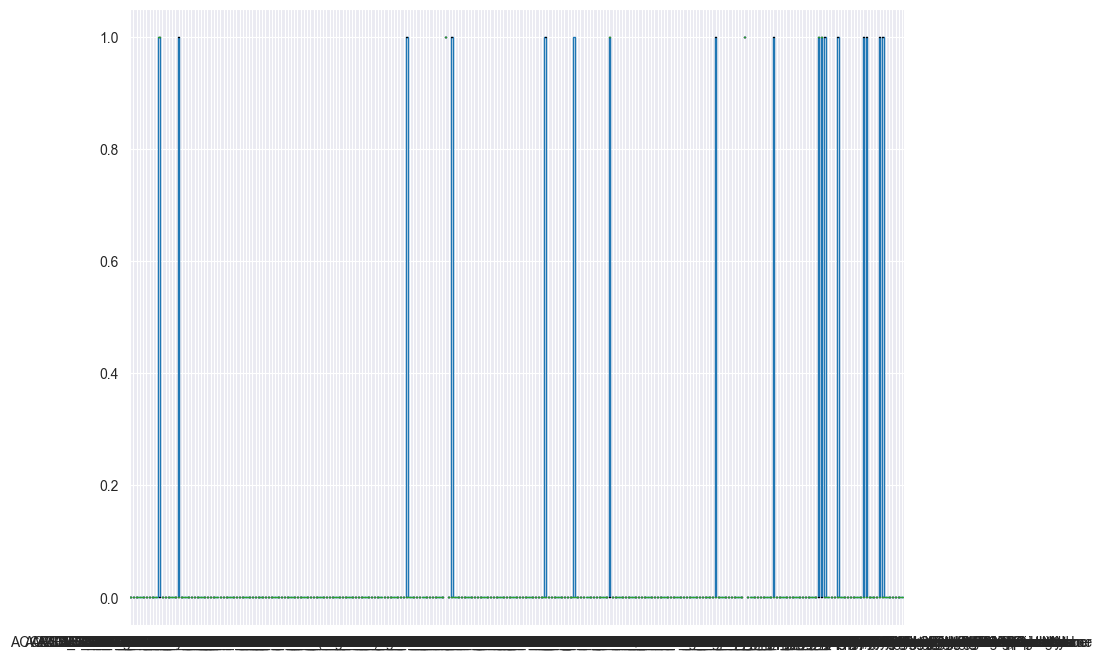

In [76]:
boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, figsize=(10,8))
plt.show()

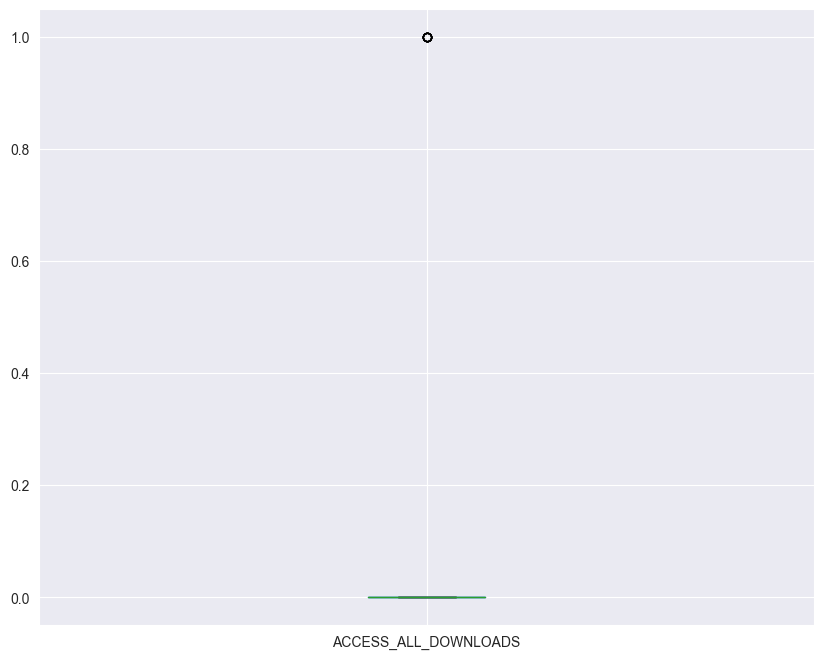

In [77]:
boxplot = features.boxplot(grid=True, fontsize=10, column="ACCESS_ALL_DOWNLOADS", figsize=(10,8))
plt.show()

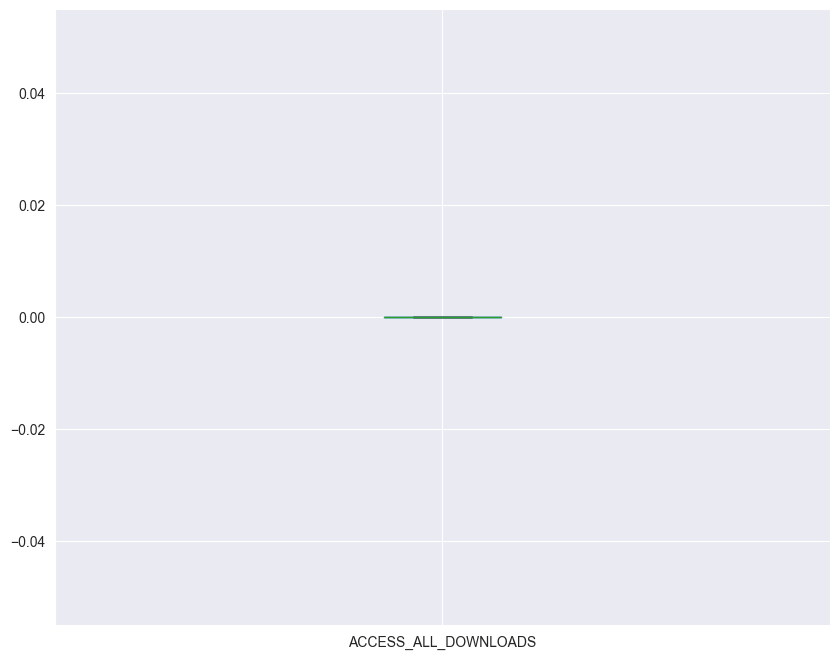

In [78]:
boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, column="ACCESS_ALL_DOWNLOADS", figsize=(10,8))
plt.show()

In [79]:
from matplotlib import pyplot as plt
import seaborn as sns

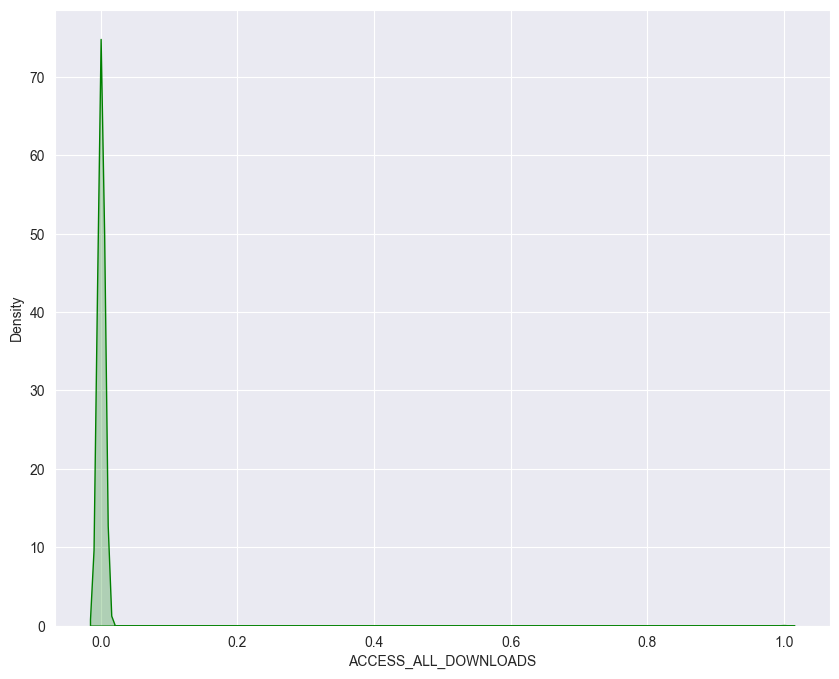

In [80]:
plt.figure(figsize=(10,8))
sns.kdeplot(features.ACCESS_ALL_DOWNLOADS, shade=True, color='green')
plt.show()

C:\Users\User\anaconda3\lib\site-packages\seaborn\distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)


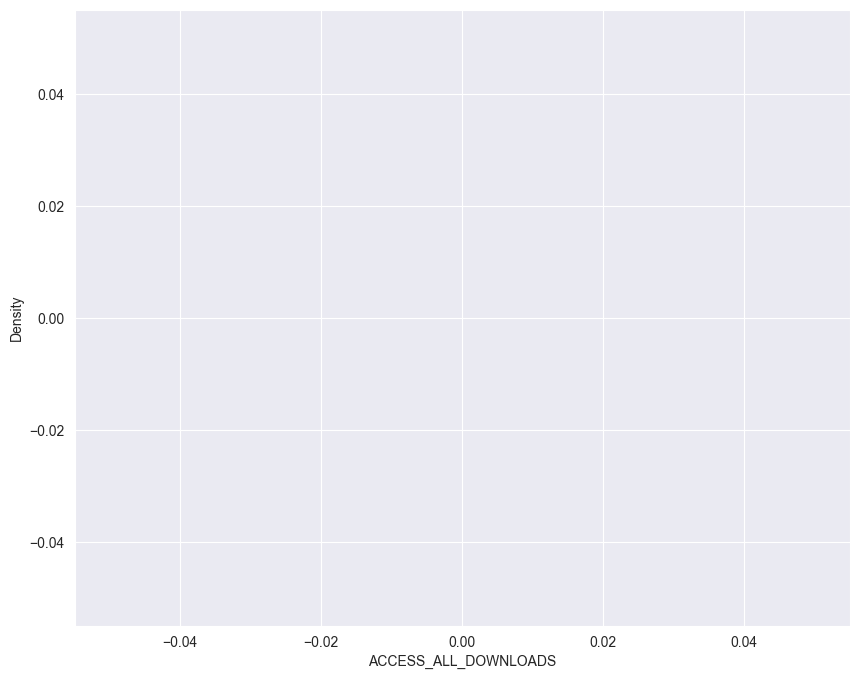

In [81]:
plt.figure(figsize=(10,8))
sns.kdeplot(features_outlier_handler.ACCESS_ALL_DOWNLOADS, shade=True, color='green')
plt.show()

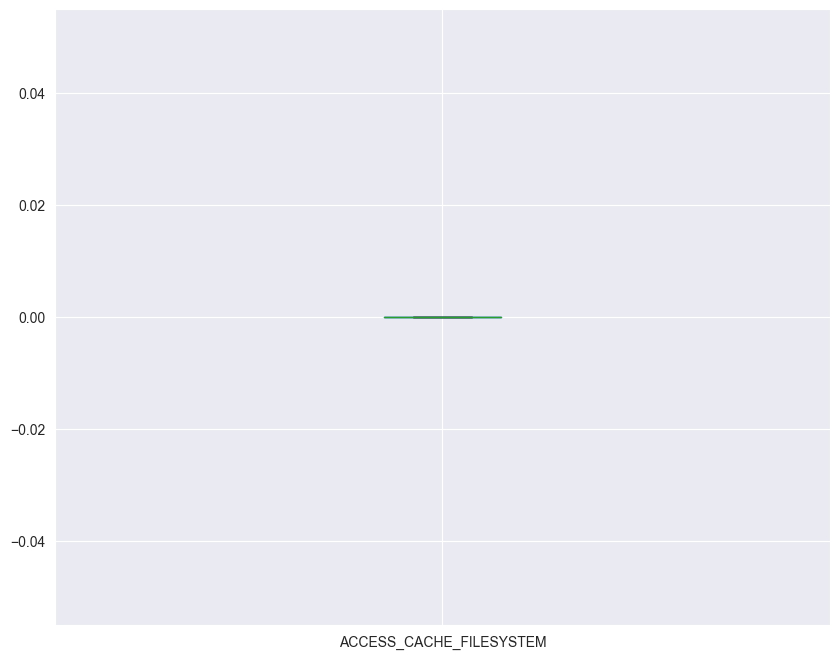

In [82]:
boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, column="ACCESS_CACHE_FILESYSTEM", figsize=(10,8))
plt.show()

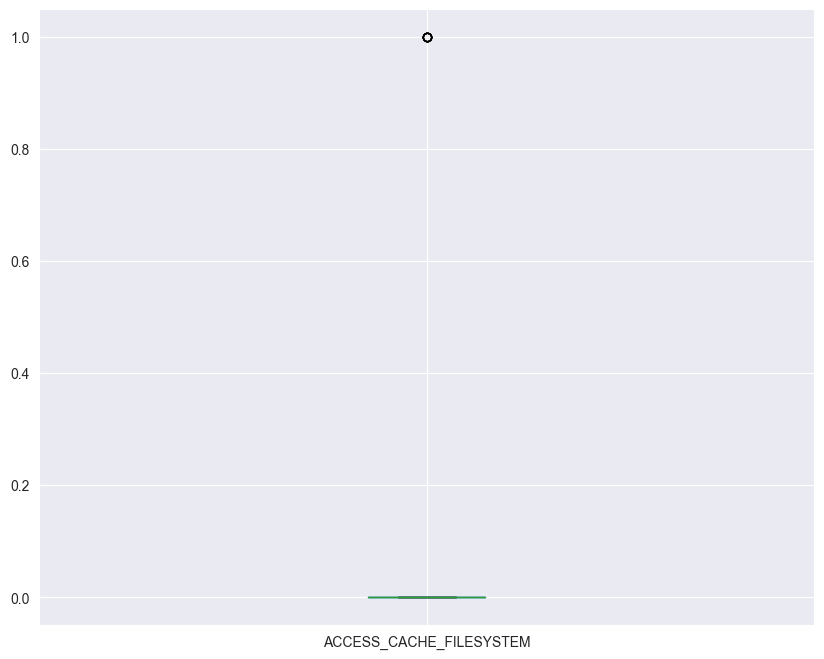

In [83]:
boxplot = features.boxplot(grid=True, fontsize=10, column="ACCESS_CACHE_FILESYSTEM", figsize=(10,8))
plt.show()

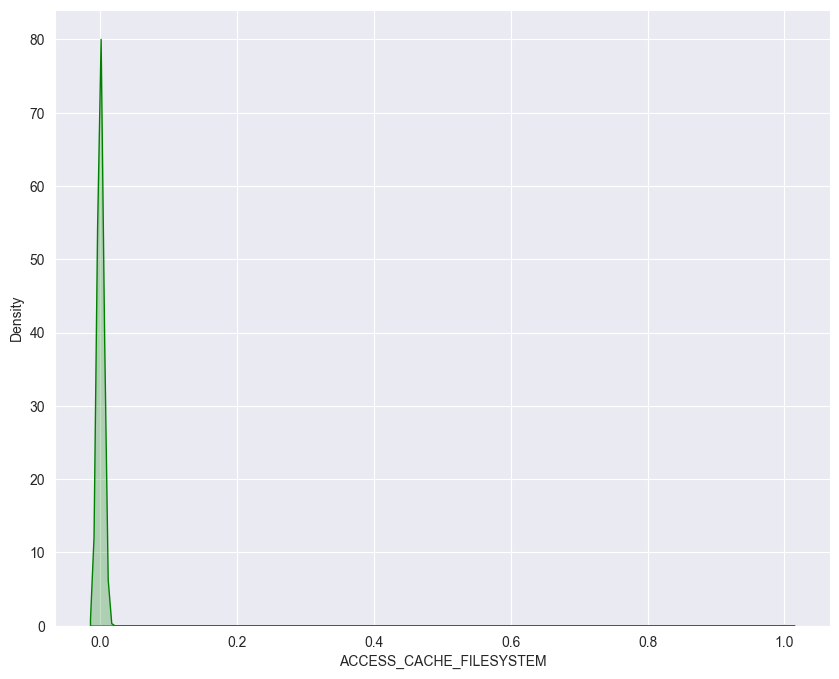

In [84]:
plt.figure(figsize=(10,8))
sns.kdeplot(features.ACCESS_CACHE_FILESYSTEM, shade=True, color='green')
plt.show()

C:\Users\User\anaconda3\lib\site-packages\seaborn\distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)


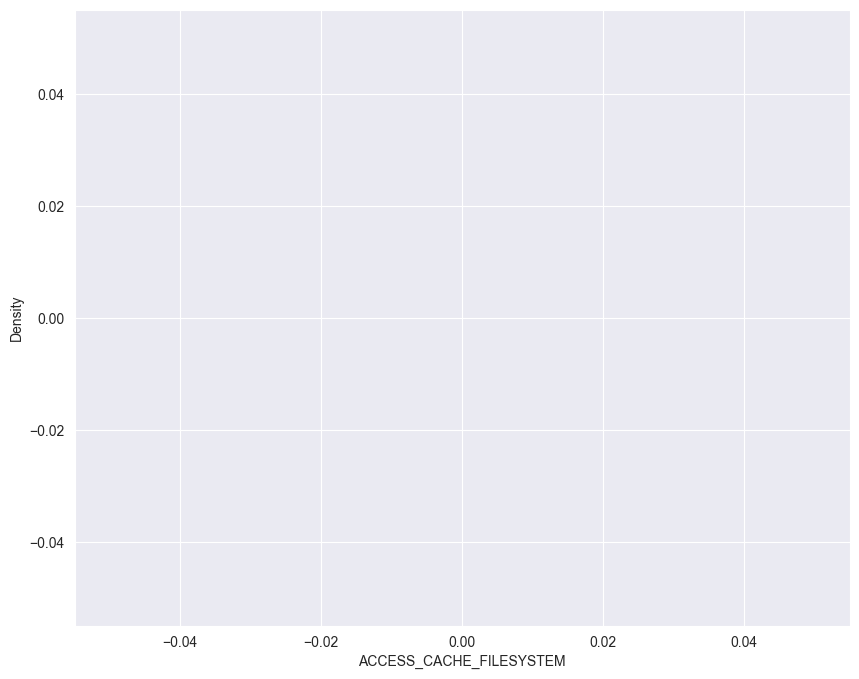

In [85]:
plt.figure(figsize=(10,8))
sns.kdeplot(features_outlier_handler.ACCESS_CACHE_FILESYSTEM, shade=True, color='green')
plt.show()

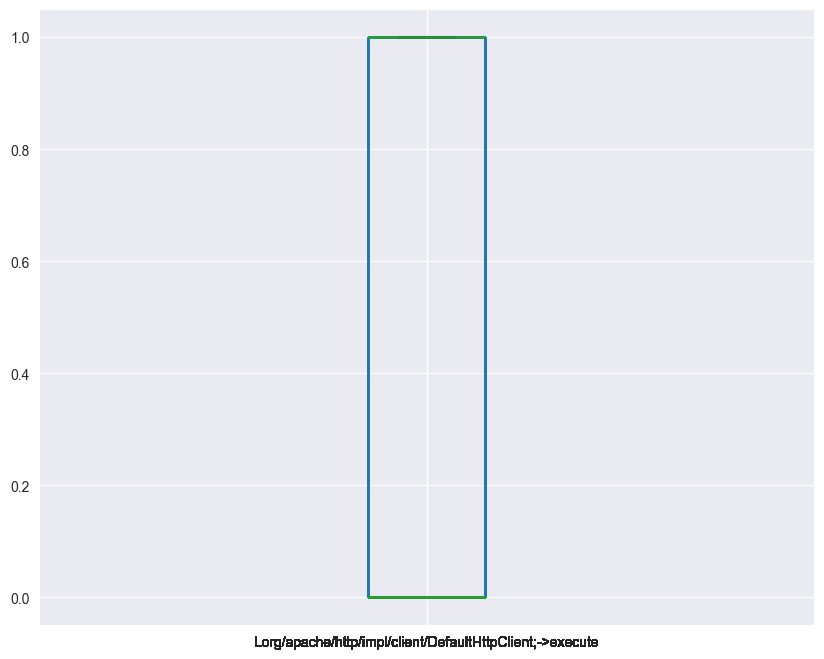

In [86]:
for colName in features_outlier_handler:
    boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, column= colName, figsize=(10,8))
plt.show()

# 4-Normalization(Scalling)

# 4.1-MinMax Scalling

In [87]:
from sklearn.preprocessing import MinMaxScaler

In [88]:
norm = MinMaxScaler()
features_outlier_handler_norm = norm.fit_transform(features_outlier_handler)

In [89]:
features_outlier_handler_norm

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [90]:
features_outlier_handler_norm = pd.DataFrame(features_outlier_handler_norm, columns=features_outlier_handler.columns)

In [91]:
features_outlier_handler_norm

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
features_outlier_handler_norm.describe()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
count,7130.0,7130.0,7130.0,7130.0,7130.0,7130.0,7130.0,7130.0,7130.0,7130.000000,...,7130.0,7130.0,7130.000000,7130.000000,7130.0,7130.0,7130.0,7130.0,7130.0,7130.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.639832,...,0.0,0.0,0.351332,0.286115,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.480083,...,0.0,0.0,0.477420,0.451976,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,...,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,...,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
features_outlier_handler_norm.shape

(7130, 241)

In [94]:
features_outlier_handler_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7130 entries, 0 to 7129
Columns: 241 entries, ACCESS_ALL_DOWNLOADS to Lorg/apache/http/impl/client/DefaultHttpClient;->execute
dtypes: float64(241)
memory usage: 13.1 MB


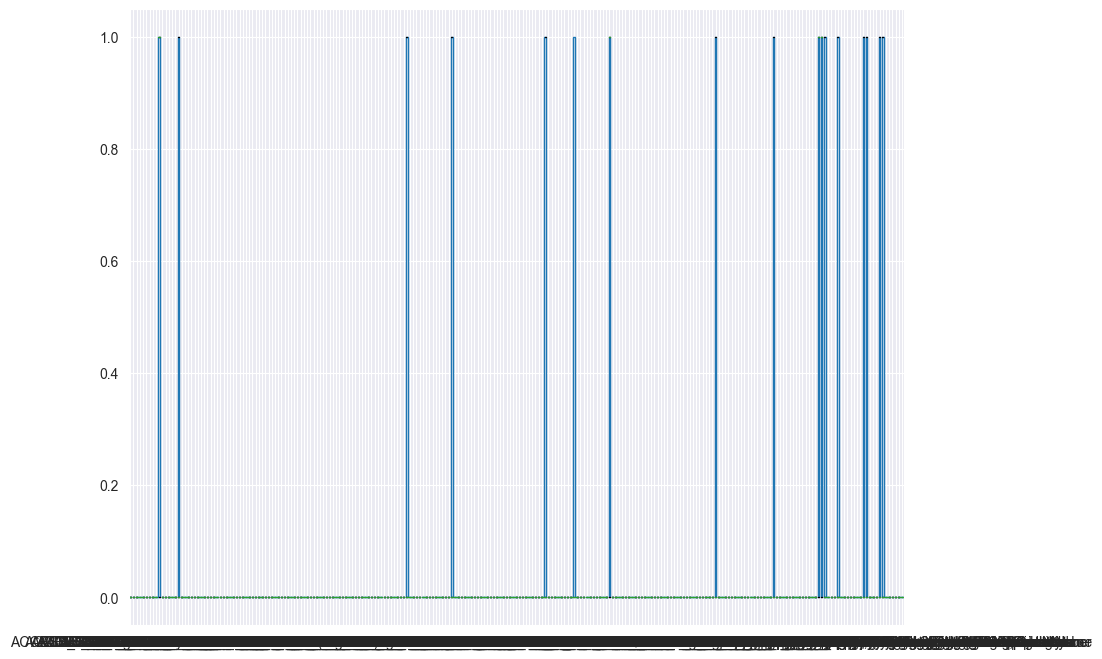

In [95]:
boxplot = features_outlier_handler_norm.boxplot(grid=True, fontsize=10, figsize=(10,8))
plt.show()

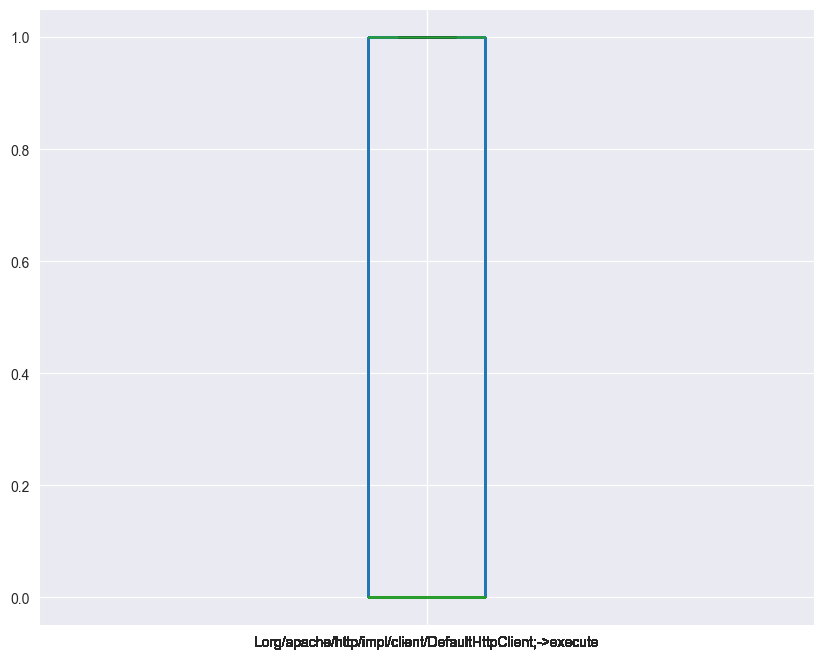

In [96]:
for colName in features_outlier_handler_norm:
    boxplot = features_outlier_handler_norm.boxplot(grid=True, fontsize=10, column= colName, figsize=(10,8))
plt.show()

In [97]:
classes

0       1
1       1
2       1
3       1
4       1
       ..
7125    0
7126    0
7127    0
7128    0
7129    0
Name: Class, Length: 7130, dtype: int64

In [98]:
features_outlier_handler_norm

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
features_outlier_handler_norm["Class"] = classes

In [100]:
features_outlier_handler_norm

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [101]:
Counter(features_outlier_handler_norm.Class)

Counter({1: 3565, 0: 3565})

# creating a csv from the resulting data

In [115]:
features["Class"] = classes

In [116]:
features

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,0,0,0
7126,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,1,...,0,1,1,1,1,1,1,0,0,0
7128,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,0,0,0


In [117]:
features.to_csv("features_outlier_handler_norm_two_classes_only.csv", index=False)